# Figures for Meeting 5 of the Physics 225 Notebook

Focuses on Vectors

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 

plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

fsize = 9
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": fsize,
    "axes.titlesize": fsize,
    "axes.labelsize": fsize,
    "xtick.labelsize": fsize,
    "ytick.labelsize": fsize,
    "legend.fontsize": fsize,
})

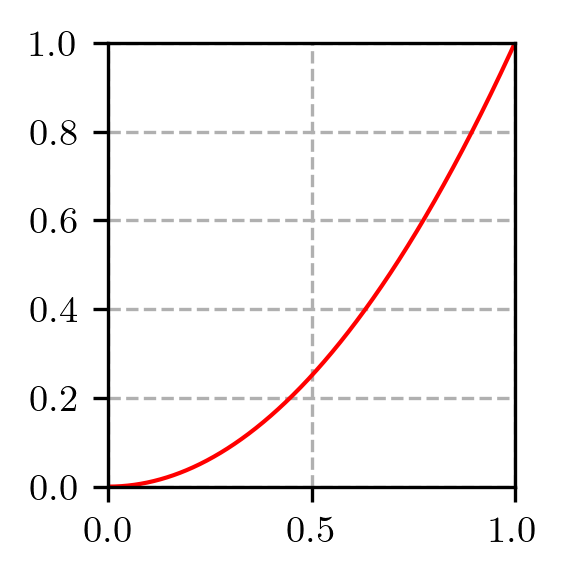

In [ ]:
figname = r'..\images\fig1.pdf'

x = np.linspace(0,1,1000)
y = x**2 

plt.figure(figsize = (2,2),dpi = 300)
plt.plot(x,y,'r-', lw = 1)
plt.xlim(x.min(),x.max())
plt.ylim(0,1)
plt.grid(linestyle = '--')
plt.tight_layout()
plt.savefig(figname)
plt.show()

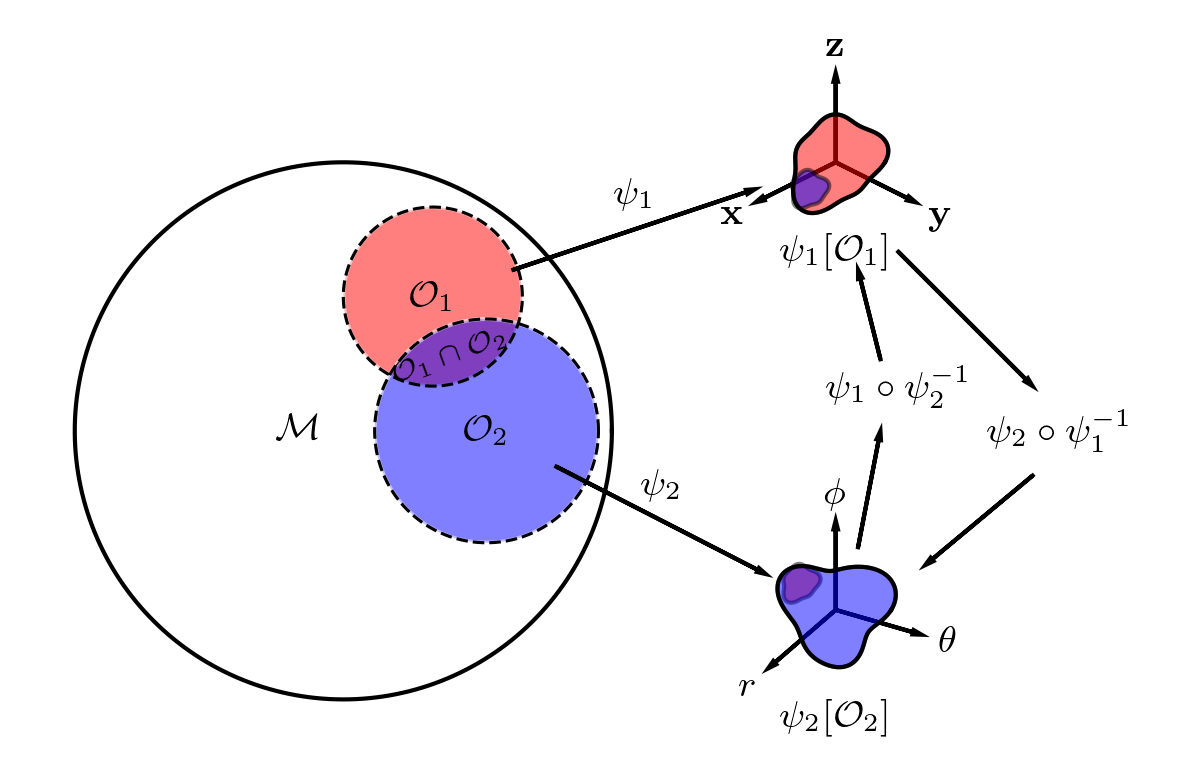

In [ ]:
fig3 = r'..\images\manifold_example.pdf'

plt.figure(figsize=(4, 3), dpi=300)
plt.gca().set_aspect('equal')


# =========================================================
# Manifold M
# =========================================================

theta = np.linspace(0, 2*np.pi, 500)

radius = 3

manifold = np.array([
    radius * np.cos(theta),
    radius * np.sin(theta)
])

plt.plot(
    manifold[0],
    manifold[1],
    'k-',
    lw=1
)

plt.annotate(
    r'$\mathcal{M}$',
    [-0.5, 0],
    ha='center',
    va='center'
)


# ---------------------------------------------------------
# Blob function
# ---------------------------------------------------------

def blob(theta, scale=1, phase=0, a = 0.15, b = 0.10, c = 0.07):
    r = scale * (
        1
        + a * np.sin(2*theta + phase)
        + b * np.cos(3*theta - phase)
        + c * np.sin(5*theta + 0.5*phase)
    )

    return r*np.cos(theta), r*np.sin(theta)
# =========================================================
# Manifold O_1
# =========================================================

radius = 1
posM1 = [1,1.5]
manifoldO1 = np.array([
    radius * np.cos(theta) + posM1[0],
    radius * np.sin(theta) + posM1[1]
])

plt.fill(
    manifoldO1[0],
    manifoldO1[1],
    facecolor='red',
    alpha = 0.5,
    edgecolor='w',
    linewidth=1
)

plt.plot(
    manifoldO1[0],
    manifoldO1[1],
    'k--',
    lw=0.75
)

plt.annotate(
    r'$\mathcal{O}_1$',
    posM1,
    ha='center',
    va='center'
)


# =========================================================
# Manifold O_2
# =========================================================

radius = 1.25
posM2 = [1.6,0]
manifoldO2 = np.array([
    radius * np.cos(theta) + posM2[0],
    radius * np.sin(theta) + posM2[1]
])

plt.fill(
    manifoldO2[0],
    manifoldO2[1],
    facecolor='blue',
    alpha = 0.5,
    edgecolor='w',
    linewidth=1
)
plt.plot(
    manifoldO2[0],
    manifoldO2[1],
    'k--',
    lw=0.75
)

plt.annotate(
    r'$\mathcal{O}_2$',
    posM2,
    ha='center',
    va='center'
)


# =========================================================
# Coordinate axes
# =========================================================

def draw_axis(
    pos,
    axisname=None,
    azimuth=-135,
    elevation=30,
    axislen=1
):

    # Convert degrees -> radians
    azimuth = np.deg2rad(azimuth)
    elevation = np.deg2rad(elevation)

    # Original coordinate axes
    ax1 = np.array([1, 0])
    ax2 = np.array([0, 1])
    ax3 = np.array([0, 1])

    # Azimuthal rotation
    az_transform = np.array([
        [np.cos(azimuth), -np.sin(azimuth)],
        [np.sin(azimuth),  np.cos(azimuth)]
    ])

    # Elevation projection
    el_transform = np.array([
        [1, 0],
        [0, np.sin(elevation)]
    ])

    # Transform axes
    ax1 = el_transform @ az_transform @ ax1
    ax2 = el_transform @ az_transform @ ax2
    ax3 = el_transform @ ax3

    axes = [ax1, ax2, ax3]

    # Default labels
    if axisname is None:
        labels = ['$\\mathbf{1}$', '$\\mathbf{2}$', '$\\mathbf{n}$']
    else:
        labels = axisname

    for ax, label in zip(axes, labels):

        # Normalize so axislen is the actual arrow length
        ax = ax / np.linalg.norm(ax)

        plt.arrow(
            pos[0],
            pos[1],
            axislen * ax[0],
            axislen * ax[1],
            color='k',
            linewidth=1,
            head_width=0.05,
            head_length=0.1,
            length_includes_head=True
        )

        plt.annotate(
            label,
            [
                pos[0] + 1.3 * axislen * ax[0],
                pos[1] + 1.3 * axislen * ax[1]
            ],
            ha='center',
            va='center'
        )

axis1pos = [5.5,3]
draw_axis(
    axis1pos,
    axisname=[r'$\mathbf{x}$', r'$\mathbf{y}$', r'$\mathbf{z}$'],
    azimuth=-135,
    elevation=30,
    axislen=1
)
axis2pos = [5.5,-2]
draw_axis(
    axis2pos,
    axisname=[r'$r$', r'$\theta$', r'$\phi$'],
    azimuth=-120,
    elevation=30,
    axislen=1
)
# ================================================
# Images
# ================================================

x, y = blob(theta, 0.5,0)
plt.fill(
    x + axis1pos[0], y + axis1pos[1],
    facecolor='red',
    alpha = 0.5,
    edgecolor='k',
    linewidth=1
)
plt.plot(x + axis1pos[0],y + axis1pos[1], 'k-',lw=1)

x, y = blob(theta, 0.2,0, 0.1,0.1)
plt.fill(
    x + axis2pos[0]-0.4, y + axis2pos[1]+0.3,
    facecolor='red',
    alpha = 0.5,
    edgecolor='k',
    linewidth=1
)
x, y = blob(theta, 0.6,1.5, 0.1, 0.2, 0.05)
plt.fill(
    0.9 * x + axis2pos[0], y + axis2pos[1],
    facecolor='blue',
    alpha = 0.5,
    edgecolor='k',
    linewidth=1
)
plt.plot(0.9 * x + axis2pos[0],y + axis2pos[1], 'k-',lw=1)

# ================================================
# Maps
# ================================================
Ox1_vec = np.array(axis1pos) - np.array(posM1)
Ox2_vec = np.array(axis2pos) - np.array(posM2)
plt.arrow(
    posM1[0] + Ox1_vec[0] * 0.2,
    posM1[1] + Ox1_vec[1] * 0.2,
    Ox1_vec[0] * 0.6,
    Ox1_vec[1] * 0.6,
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    color='k',
    length_includes_head=True
)
plt.arrow(
    posM2[0] + Ox2_vec[0] * 0.2,
    posM2[1] + Ox2_vec[1] * 0.2,
    Ox2_vec[0] * 0.6,
    Ox2_vec[1] * 0.6,
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    color='k',
    length_includes_head=True
)
plt.annotate(
    r"$\psi_1$",
    np.array(posM1) + Ox1_vec/2 + np.array([0,0.4]),
    ha='center',
    va='center'
)
plt.annotate(
    r"$\psi_2$",
    np.array(posM2) + Ox2_vec/2 + np.array([0,0.4]),
    ha='center',
    va='center'
)
plt.annotate(
    r"$\psi_1[\mathcal{O}_1]$",
    axis1pos + np.array([0,- 1]),
    ha='center',
    va='center'
)
plt.annotate(
    r"$\psi_2[\mathcal{O}_2]$",
    axis2pos + np.array([0,- 1.2]),
    ha='center',
    va='center'
)
# Differentiability
plt.annotate(
    r"$\mathcal{O}_1 \cap \mathcal{O}_2$",
    [1.2,0.85],
    ha='center',
    va='center',
    rotation = 20,
    fontsize = 7
)
# intersection blobs

x, y = blob(theta, 0.2,0, 0.05)
plt.fill(
    x + axis1pos[0]-0.3, y + axis1pos[1]-0.3,
    facecolor='blue',
    alpha = 0.5,
    edgecolor='k',
    linewidth=1
)

# --------------------------------------------------
# Labels


plt.annotate(
    r"$\psi_1 \circ \psi_2^{-1}$",
    [6.2,0.5],
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$\psi_2 \circ \psi_1^{-1}$",
    [8.0,0],
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)


plt.arrow(
    5.75,-1.3,
    6-5.75,0--1.3,
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    color='k',
    length_includes_head=True
)

plt.arrow(
    6,0.8,
    5.75-6, 1.8-0.8,
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    color='k',
    length_includes_head=True
)

arpos0 = np.array([6.2,2])
arposf = np.array([7.7,0.5])
arrvec = arposf - arpos0
plt.arrow(
    *arpos0,
    *arrvec,
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    color='k',
    length_includes_head=True
)

arpos0 = np.array([7.7, - 0.5])
arposf = np.array([6.5,-1.5])
arrvec = arposf - arpos0
plt.arrow(
    *arpos0,
    *arrvec,
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    color='k',
    length_includes_head=True
)
# =========================================================
# Formatting
# =========================================================

plt.axis(False)
plt.xlim(-3.5,9)
# plt.grid(which='both')
plt.tight_layout()
plt.savefig(fig3)
plt.show()


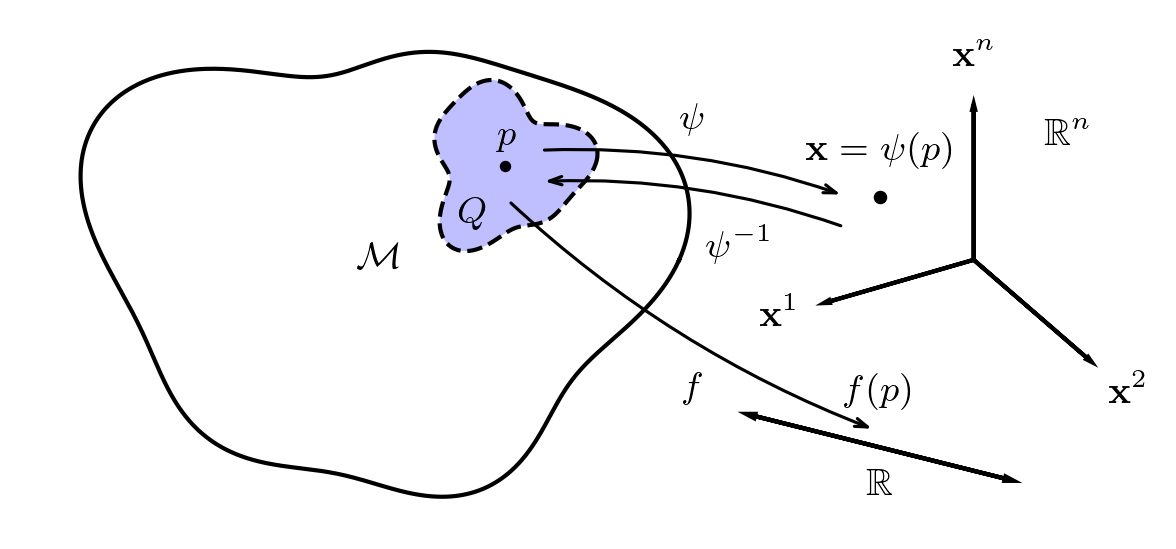

In [ ]:
figname = r'..\images\manifoldtoscalar.pdf'
from matplotlib.patches import FancyArrowPatch

plt.figure(figsize=(4,2), dpi=300)
plt.gca().set_aspect('equal')

theta = np.linspace(0, 2*np.pi, 1000)
u, v = blob(theta, 4, 1.6)
plt.plot(u, v, 'k-', lw=1)

p = np.array([2,1.5])
plt.scatter(*p, color='k',s=3, zorder = 4)
plt.annotate(
    r"$p$",
    p + np.array([0,0.5]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

u,v = blob(theta, 1.2, 0,0, 0.2,0.1) + p.reshape(2,1)
plt.fill(
    u,v,
    facecolor ='b',
    edgecolor = None,
    alpha = 0.25)
plt.plot(u, v, 'k--', lw=1)

draw_axis(
    [9.5, 0],
    [
        r"$\mathbf{x}^1$",
        r"$\mathbf{x}^2$",
        r"$\mathbf{x}^n$"
    ],
    -150,
    30,
    2.5
)

R0 = np.array([6,-2.5])
RE = np.array([10,-3.5])
R1 = R0 - RE
R2 = RE - R0

plt.arrow(
    *R0,
    *R2,
    linewidth=1,
    head_width=0.075,
    head_length=0.15,
    color='k'
)

plt.arrow(
    *RE,
    *R1,
    linewidth=1,
    head_width=0.075,
    head_length=0.15,
    color='k'
)

RNpos = (RE + R0)/2 - np.array([0,0.6])
plt.annotate(
    r"$\mathbb{R}$",
    RNpos,
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$\mathbb{R}^n$",
    [11,2],
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

fp = np.array([8,1])
plt.scatter(
    fp[0],
    fp[1],
    color='k',
    s=5
)
plt.annotate(
    r"$\mathbf{x}=\psi(p)$",
    fp + np.array([0,0.75]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$\mathcal{M}$",
    [0,0],
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$Q$",
    p + np.array([-0.5,-0.75]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

arrow1 = FancyArrowPatch(
    p + np.array([0, -0.5]),
    (R0 + RE)/2 + np.array([0, 0.25]),
    connectionstyle="arc3,rad=0.1",
    arrowstyle='->,head_width=1,head_length=3',  # <-- Control head size
    color='k',
    linewidth=0.75
)
arrow2 = FancyArrowPatch(
    p + np.array([0.5, 0.25]),
    fp + np.array([-0.5, 0]),
    connectionstyle="arc3,rad=-0.1",
    arrowstyle='->,head_width=1,head_length=3',  # <-- Control head size
    color='k',
    linewidth=0.75
)

arrow3 = FancyArrowPatch(
    fp + np.array([-0.5, 0- 0.5]),
    p + np.array([0.5, 0.25 - 0.5]),
    connectionstyle="arc3,rad=0.1",
    arrowstyle='->,head_width=1,head_length=3',  # <-- Control head size
    color='k',
    linewidth=0.75
)

plt.annotate(
    r"$\psi$",
    p + (fp - p)/2 + np.array([0,1]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$\psi^{-1}$",
    p + (fp - p)/2 + np.array([0.75,-1]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)


plt.annotate(
    r"$f$",
    p + (RNpos - p)/2 + np.array([0,-1]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)

plt.annotate(
    r"$f(p)$",
    RNpos + np.array([0, 1.5]),
    ha='center',
    va='center',
    rotation = 0,
    fontsize = 9
)


plt.gca().add_patch(arrow1) 
plt.gca().add_patch(arrow2) 
plt.gca().add_patch(arrow3) 
# plt.xlim(-5,10)
plt.axis('off')
# plt.grid(False)
# plt.grid(zorder=0)
plt.tight_layout()   
plt.savefig(figname)
plt.show()


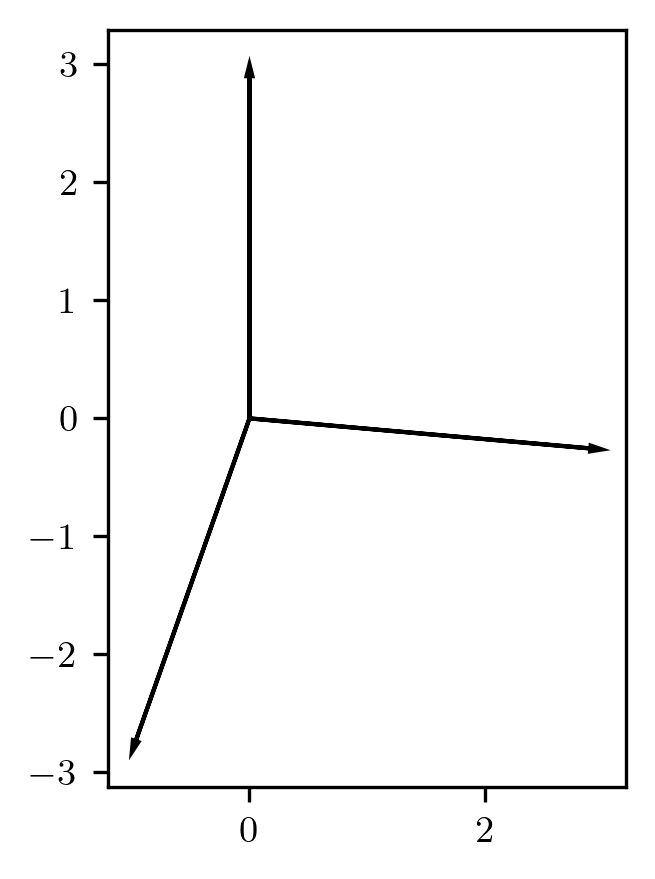

In [ ]:

figname = r"..\images\R3vectors.pdf"

plt.figure(figsize = (4,3), dpi = 300)
plt.gca().set_aspect('equal')

draw_axis(
    [0,0],
    [
        r'$x$',
        r'$y$',
        r'$yz',
    ],
    -100,
    20,
    3
)

plt.xlim(-2,3)
plt.ylim(-4,4)

plt.tight_layout()
plt.savefig(figname)
plt.show()


